In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qc_lib
%matplotlib inline

## Parameters

QC for the indel benchmark sets (`--indel_t 4`), compared against the SNP sets
of the same release. Run from `src/`.

In [2]:
MODS      = qc_lib.MODS
INDEL_DIR = "../data/gtex11/indel"   # indel sets
SNP_DIR   = "../data/gtex11/snp"     # SNP sets, for reference
INDEL_T   = 4

## Load

Everything needed is already in the VCF INFO fields and `matches.tsv`; no rejoin
to the parquets is required. Loading is shared with the SNP notebooks via
[qc_lib.py](qc_lib.py), which normalizes the modality-specific feature-distance
field (`TSSD`/`SD`/`PD`) to `dist` and computes `ilen = len(ALT) - len(REF)`.

In [3]:
indel = {m: qc_lib.load_set(INDEL_DIR, m) for m in MODS}
match = {m: qc_lib.load_matches(INDEL_DIR, m) for m in MODS}

for m in MODS:
    d = indel[m]
    d["type"] = np.where(d.ilen > 0, "INS", np.where(d.ilen < 0, "DEL", "SNP"))
    d["L"] = d.ilen.abs()
    print(f"{m:6s} tissue-level: {(d.label=='pos').sum():5d} pos / {(d.label=='neg').sum():5d} neg"
          f"   unique pos variants: {d[d.label=='pos'].variant_id.nunique():5d}")

eqtl   tissue-level:  3352 pos /  3344 neg   unique pos variants:  1392
sqtl   tissue-level:  2857 pos /  2857 neg   unique pos variants:  1105
paqtl  tissue-level:  1186 pos /  1186 neg   unique pos variants:   349


## QC 0: allele invariants

Every record must be a pure left-anchored indel of length ≤ `INDEL_T`. Matched
pairs must share `ilen` exactly — same event type, same size — since that is the
bucket key. Nucleotide identity is not required; the Hamming distance between the
two event alleles is charged to the score and recorded as `mismatch`.

In [4]:
for m in MODS:
    d = indel[m]
    pure = (d.L.between(1, INDEL_T)
            & (d[["ref", "alt"]].apply(lambda r: min(len(r.ref), len(r.alt)) == 1, axis=1))
            & (d[["ref", "alt"]].apply(lambda r: r.ref[0] == r.alt[0], axis=1)))
    ilen = d.drop_duplicates("variant_id").set_index("variant_id").ilen
    mm = match[m].dropna(subset=["neg_variant"])
    same = ilen.reindex(mm.pos_variant).values == ilen.reindex(mm.neg_variant).values
    print(f"{m:6s} pure indels \u2264{INDEL_T}bp: {pure.mean():.4%}   "
          f"matched pairs with identical ilen: {same.mean():.4%} of {len(mm):,}")

eqtl   pure indels ≤4bp: 100.0000%   matched pairs with identical ilen: 100.0000% of 3,344


sqtl   pure indels ≤4bp: 100.0000%   matched pairs with identical ilen: 100.0000% of 2,857
paqtl  pure indels ≤4bp: 100.0000%   matched pairs with identical ilen: 100.0000% of 1,186


## QC 1: composition of the positive sets

Indel type and length distribution. Length 1 dominates; the length-4 bump is
polymorphic tetranucleotide repeats.

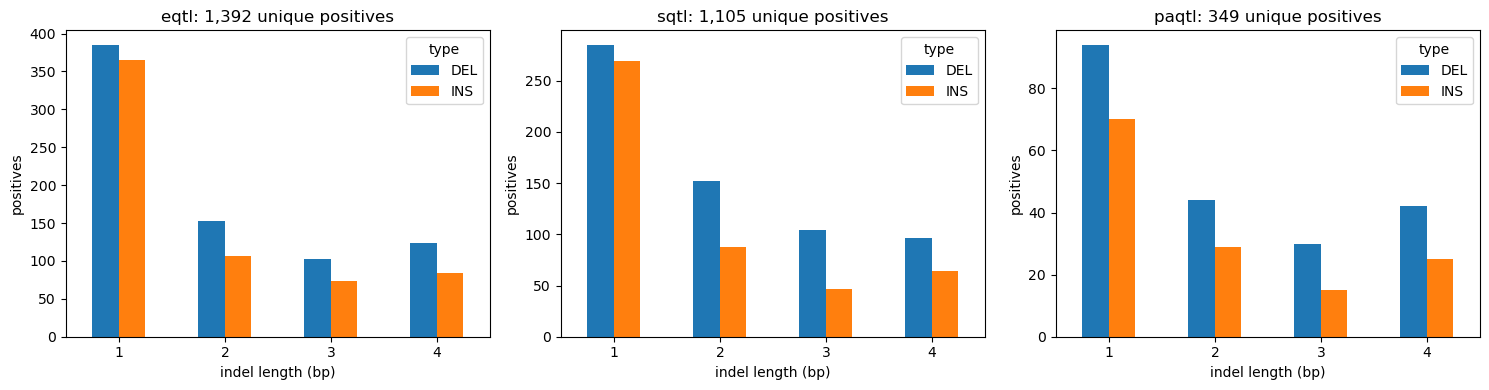

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, MODS):
    p = indel[m][indel[m].label == "pos"].drop_duplicates("variant_id")
    p.groupby(["L", "type"]).size().unstack(fill_value=0).plot.bar(ax=ax, rot=0)
    ax.set_title(f"{m}: {len(p):,} unique positives")
    ax.set_xlabel("indel length (bp)")
    ax.set_ylabel("positives")
plt.tight_layout()
plt.show()

## QC 2: match rate

The headline number. A positive goes unmatched only when its `(region, ilen)`
bucket — `(ilen,)` for sQTL/apaQTL — is empty or already exhausted. Because the
bucket no longer requires exact alleles, the eQTL CDS and UTR3 compartments, which
are depleted of indels by selection, now have candidates available.

In [6]:
for m in MODS:
    p = indel[m][indel[m].label == "pos"].copy()
    matched = pd.MultiIndex.from_arrays([match[m].tissue, match[m].pos_variant])
    p["matched"] = pd.MultiIndex.from_arrays([p.tissue, p.variant_id]).isin(matched)
    print(f"\n=== {m}: {len(p):,} tissue-level positives, "
          f"{p.matched.mean():.1%} matched")
    if p.region.notna().any():
        g = p.groupby("region").matched.agg(["size", "sum", "mean"])
        g.columns = ["positives", "matched", "rate"]
        print(g.to_string())
    g = p.groupby(["type", "L"]).matched.agg(["size", "mean"])
    g.columns = ["positives", "rate"]
    print(g.to_string())


=== eqtl: 3,352 tissue-level positives, 99.8% matched
        positives  matched      rate
region                              
CDS           221      213  0.963801
TSS          2768     2768  1.000000
UTR3          363      363  1.000000
        positives      rate
type L                     
DEL  1        928  1.000000
     2        464  0.991379
     3        228  1.000000
     4        284  0.989437
INS  1        818  1.000000
     2        234  1.000000
     3        194  1.000000
     4        202  0.995050

=== sqtl: 2,857 tissue-level positives, 100.0% matched
        positives  rate
type L                 
DEL  1        751   1.0
     2        331   1.0
     3        264   1.0
     4        188   1.0
INS  1        638   1.0
     2        315   1.0
     3        168   1.0
     4        202   1.0

=== paqtl: 1,186 tissue-level positives, 100.0% matched
        positives  rate
type L                 
DEL  1        255   1.0
     2        265   1.0
     3         78   1.0
     4 

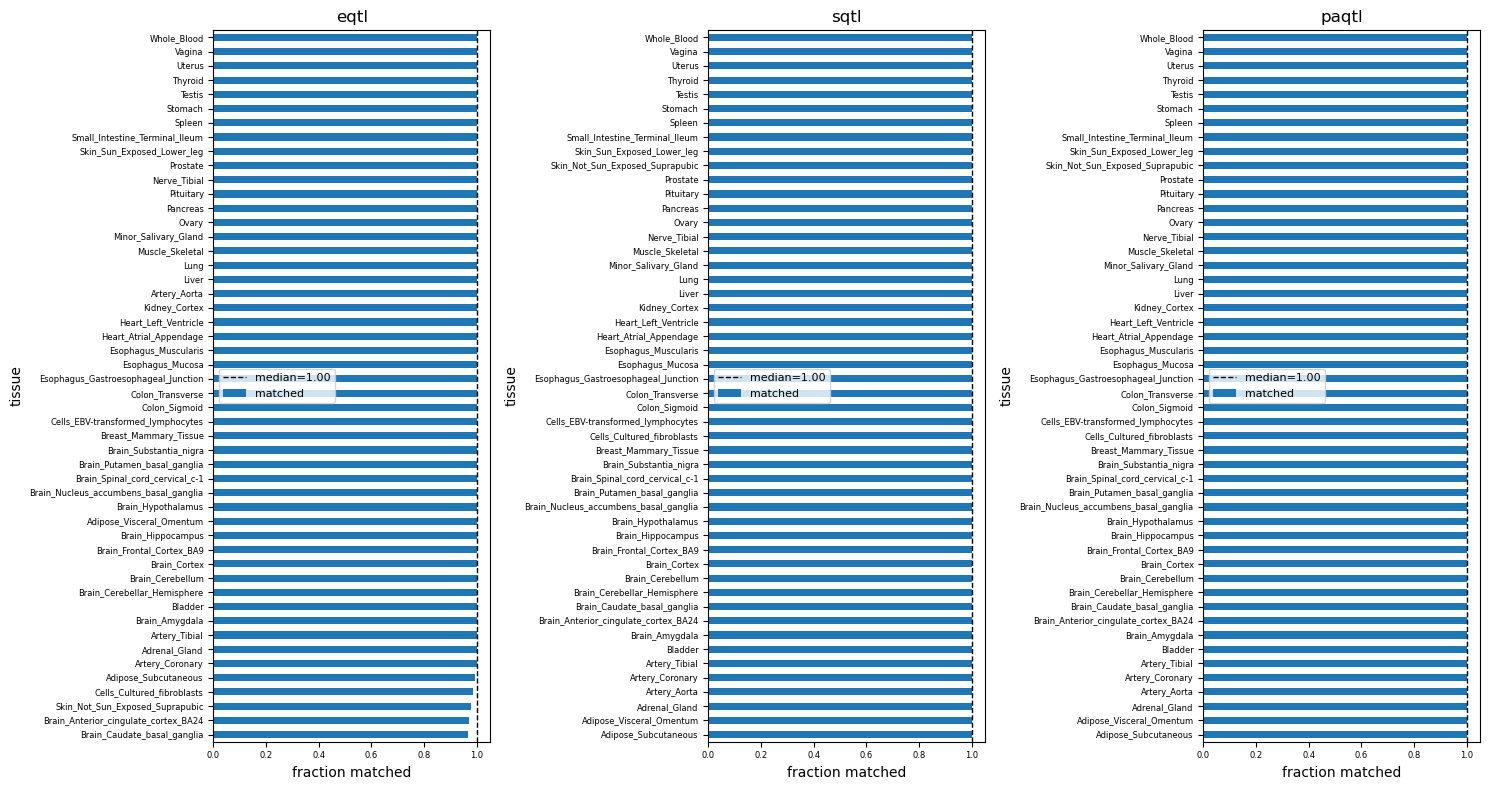

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharex=True)
for ax, m in zip(axes, MODS):
    p = indel[m][indel[m].label == "pos"].copy()
    matched = pd.MultiIndex.from_arrays([match[m].tissue, match[m].pos_variant])
    p["matched"] = pd.MultiIndex.from_arrays([p.tissue, p.variant_id]).isin(matched)
    s = p.groupby("tissue").matched.mean().sort_values()
    s.plot.barh(ax=ax)
    ax.axvline(s.median(), color="k", linestyle="--", lw=1,
               label=f"median={s.median():.2f}")
    ax.set_xlabel("fraction matched")
    ax.set_title(m)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

## QC 2b: allele mismatch cost

`mismatch` is the Hamming distance between the positive's and negative's event
allele (the longer of REF/ALT: indel bases plus the anchor). Zero means the
alleles are byte-identical. The distribution shows how much of the matching had
to fall back on the relaxation — and `score - mismatch` recovers the covariate-only
score, comparable to the SNP sets.

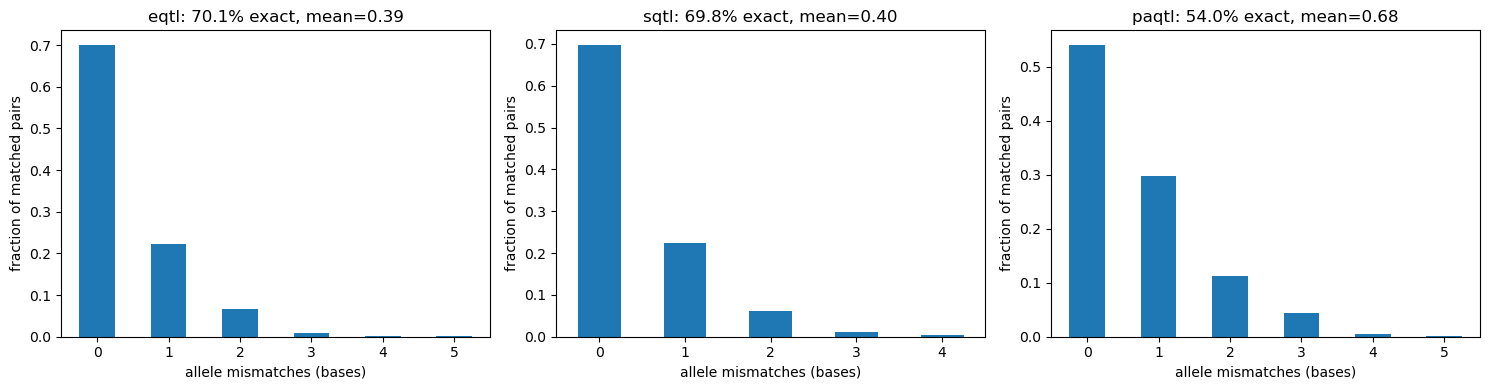


=== eqtl
                 pairs  median_covariate_score
region mismatch                               
CDS    0            23                2.104510
       1           115                1.349731
       2            55                1.343507
       3            12                1.956623
       4             1                1.752577
       5             7                2.133493
TSS    0          2116                0.649673
       1           526                0.978110
       2           117                1.060733
       3             6                1.397442
       4             3                1.347747
UTR3   0           204                0.719360
       1           102                0.740380
       2            49                0.793328
       3             8                0.558519

=== sqtl
          pairs  median_covariate_score
mismatch                               
0          1993                0.834982
1           642                1.234250
2           179      

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, MODS):
    mm = match[m].dropna(subset=["neg_variant"])
    frac = mm.mismatch.value_counts(normalize=True).sort_index()
    frac.plot.bar(ax=ax, rot=0)
    ax.set_xlabel("allele mismatches (bases)")
    ax.set_ylabel("fraction of matched pairs")
    ax.set_title(f"{m}: {frac.get(0, 0):.1%} exact, mean={mm.mismatch.mean():.2f}")
plt.tight_layout()
plt.show()

for m in MODS:
    mm = match[m].dropna(subset=["neg_variant"]).copy()
    mm["covariate_score"] = mm.score - mm.mismatch
    by = ["region", "mismatch"] if "region" in mm.columns else ["mismatch"]
    g = mm.groupby(by).agg(pairs=("score", "size"),
                           median_covariate_score=("covariate_score", "median"))
    print(f"\n=== {m}"); print(g.to_string())

## QC 3: positive vs negative marginals

The covariates the score controls for. Positives and matched negatives should
overlap; residual separation is what the model could exploit for the wrong
reasons.

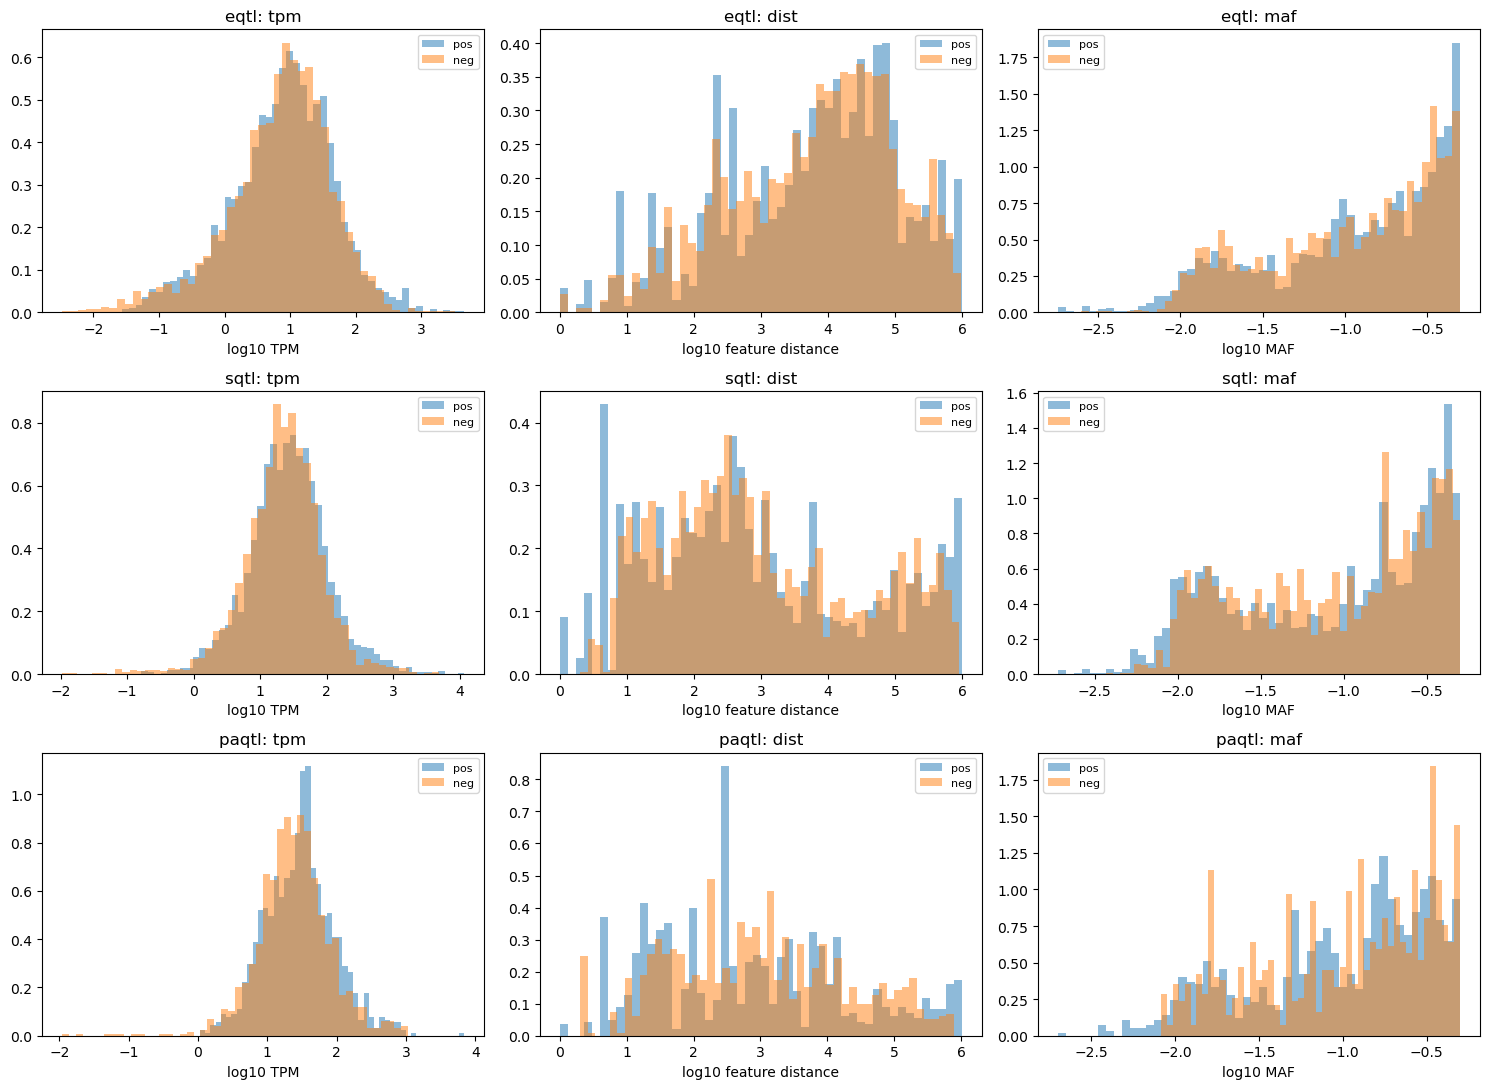

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for row, m in enumerate(MODS):
    d = indel[m]
    for col, (var, xf, xlabel) in enumerate([
        ("tpm", np.log10, "log10 TPM"),
        ("dist", lambda x: np.log10(x + 1), "log10 feature distance"),
        ("maf", np.log10, "log10 MAF"),
    ]):
        ax = axes[row, col]
        for label in ("pos", "neg"):
            v = d.loc[d.label == label, var].dropna()
            v = xf(v[v > 0]) if var != "dist" else xf(v)
            ax.hist(v, bins=50, alpha=0.5, density=True, label=label)
        ax.set_xlabel(xlabel)
        ax.set_title(f"{m}: {var}")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## QC 3b: paired covariate agreement

QC 3 compares the two *distributions*; this compares the two *members of each
pair*. Marginals can overlap perfectly while the assignment is scrambled, and only
the scatter shows that. Points are split by whether the pair took an allele
mismatch, so the cost of the relaxation is visible directly: if the orange cloud
were systematically further off-diagonal, the relaxation would be buying match rate
with covariate quality.

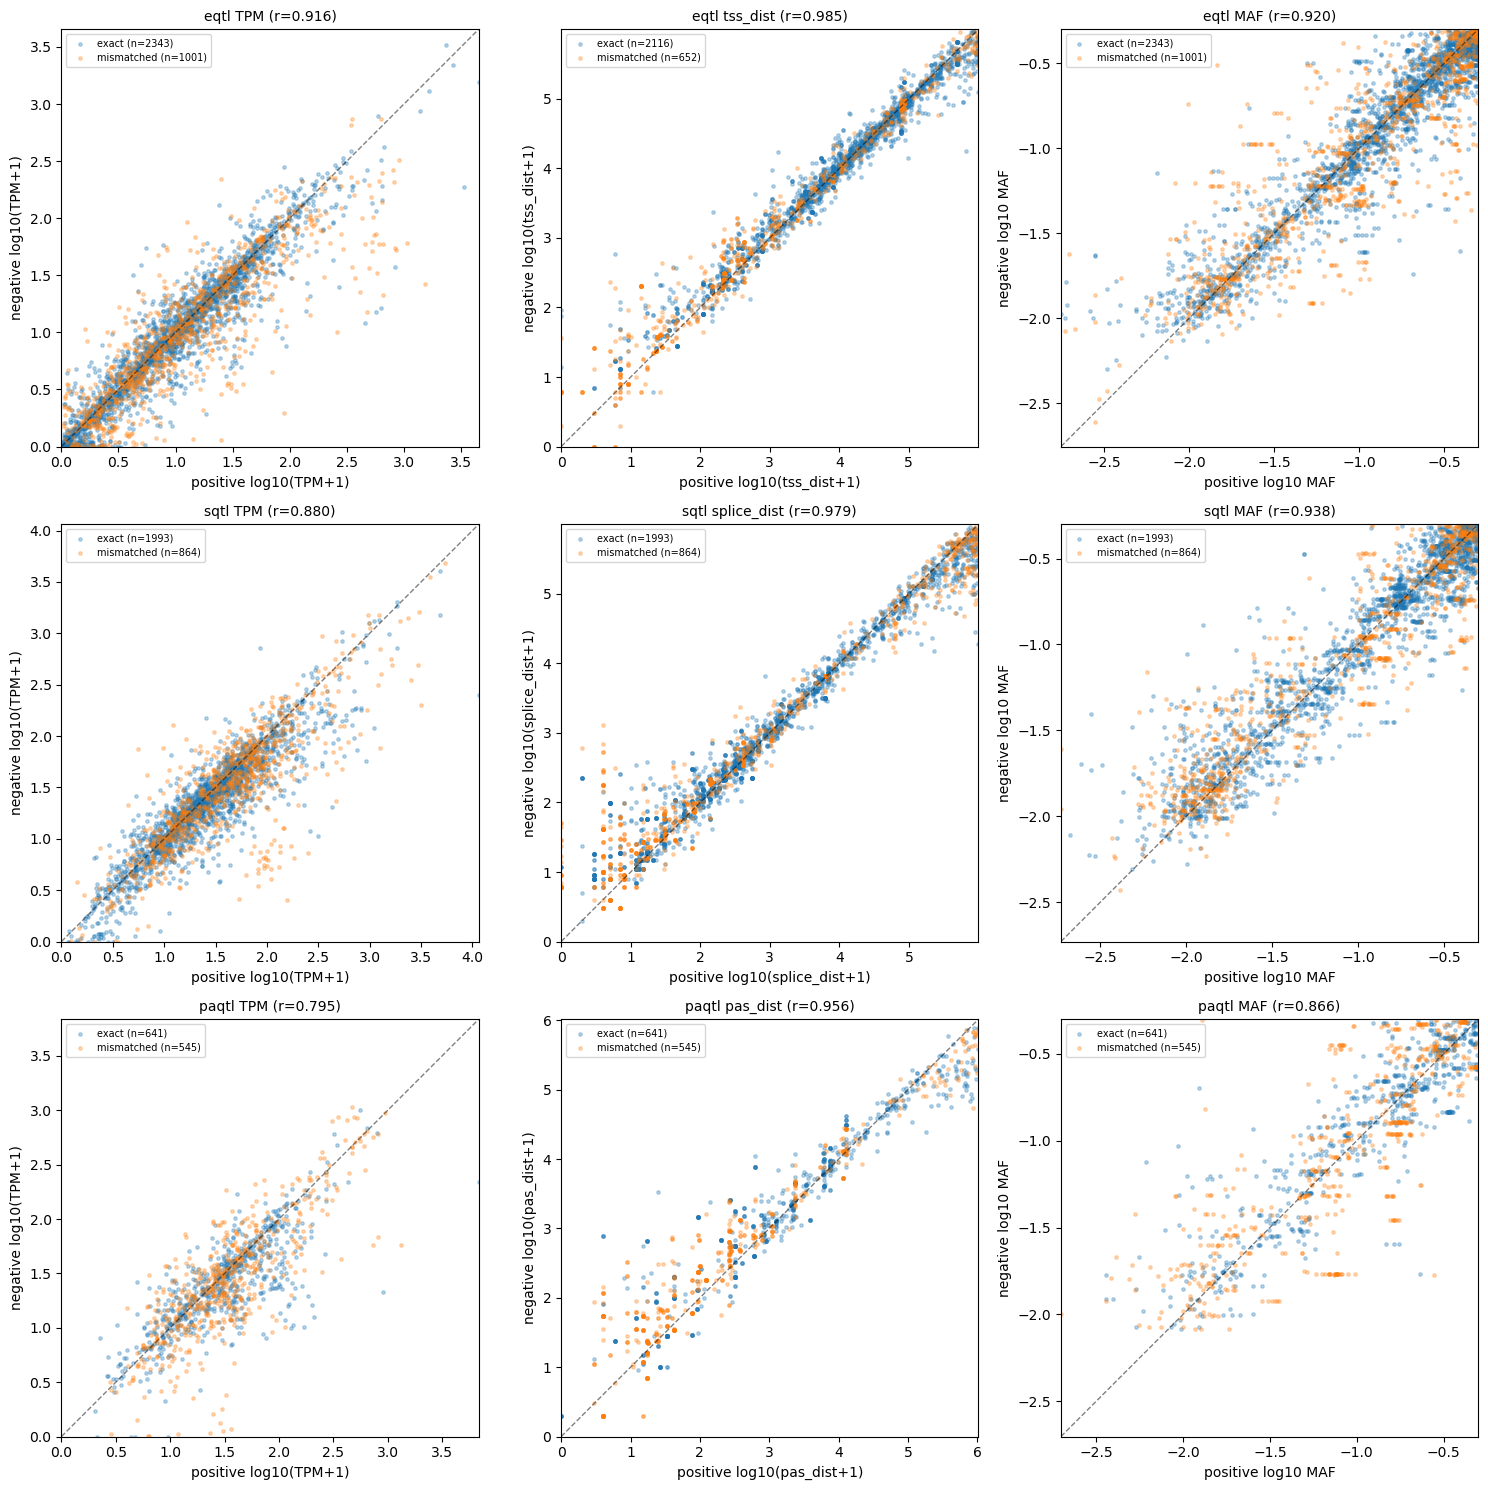

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for row, m in enumerate(MODS):
    mm = match[m].dropna(subset=["neg_variant"])
    d = qc_lib.DIST_COL[m]
    groups = [(mm.mismatch == 0, "C0", "exact"), (mm.mismatch > 0, "C1", "mismatched")]
    panels = [("TPM", np.log10(mm.pos_tpm + 1), np.log10(mm.neg_tpm + 1), "log10(TPM+1)"),
              (d, np.log10(mm[f"pos_{d}"] + 1), np.log10(mm[f"neg_{d}"] + 1), f"log10({d}+1)"),
              ("MAF", np.log10(mm.pos_maf.clip(lower=1e-3)),
               np.log10(mm.neg_maf.clip(lower=1e-3)), "log10 MAF")]
    for col, (name, x, y, label) in enumerate(panels):
        qc_lib.paired_scatter(axes[row, col], x, y, label, f"{m} {name}", groups=groups)
plt.tight_layout()
plt.show()

## QC 3c: pairing summary vs the SNP sets

The same correlations [qc.ipynb](qc.ipynb) reports for SNPs, computed here for
indels alongside their SNP counterparts. `same gene` should be near zero — a negative
drawn from the positive's own gene would not be an independent control.

In [11]:
for m in MODS:
    d = qc_lib.DIST_COL[m]
    snp = qc_lib.load_matches(SNP_DIR, m)
    tbl = pd.DataFrame({"SNP": qc_lib.pair_stats(snp, d),
                        "indel": qc_lib.pair_stats(match[m], d)})
    print(f"\n=== {m}"); print(tbl.to_string(float_format=lambda v: f"{v:.4f}"))

# eQTL only: the same correlations split by region
mm = match["eqtl"].dropna(subset=["neg_variant"])
rows = {r: qc_lib.pair_stats(g, "tss_dist") for r, g in mm.groupby("region")}
print("\n=== eqtl indels by region")
print(pd.DataFrame(rows).to_string(float_format=lambda v: f"{v:.4f}"))


=== eqtl
                       SNP     indel
pairs           58122.0000 3344.0000
r log10(TPM+1)      0.9956    0.9160
r log10(dist+1)     0.9990    0.9849
r log10(MAF)        0.9953    0.9202
same gene           0.0121    0.0018
median score        0.0867    0.7586

=== sqtl
                       SNP     indel
pairs           58517.0000 2857.0000
r log10(TPM+1)      0.9903    0.8801
r log10(dist+1)     0.9987    0.9794
r log10(MAF)        0.9934    0.9382
same gene           0.0135    0.0039
median score        0.1707    0.9426



=== paqtl
                       SNP     indel
pairs           14823.0000 1186.0000
r log10(TPM+1)      0.9834    0.7953
r log10(dist+1)     0.9977    0.9562
r log10(MAF)        0.9908    0.8658
same gene           0.0130    0.0017
median score        0.2126    1.4120

=== eqtl indels by region
                     CDS       TSS     UTR3
pairs           213.0000 2768.0000 363.0000
r log10(TPM+1)    0.6701    0.9387   0.8266
r log10(dist+1)      NaN    0.9849      NaN
r log10(MAF)      0.6153    0.9467   0.7937
same gene         0.0000    0.0011   0.0083
median score      1.5610    0.7237   0.7011


## QC 4: match score vs the SNP sets

The score is `|Δlog1p(TPM)| + |Δlog1p(dist)| + |Δlog(MAF)| + mismatch` (distance
term dropped for eQTL UTR3/CDS). Plotted here as `score - mismatch`, the
covariate-only part, which is what is comparable to the SNP sets: if the indel
distribution sits at or below the SNP band, covariate matching is at least as
tight. The allele cost paid to get there is QC 2b.

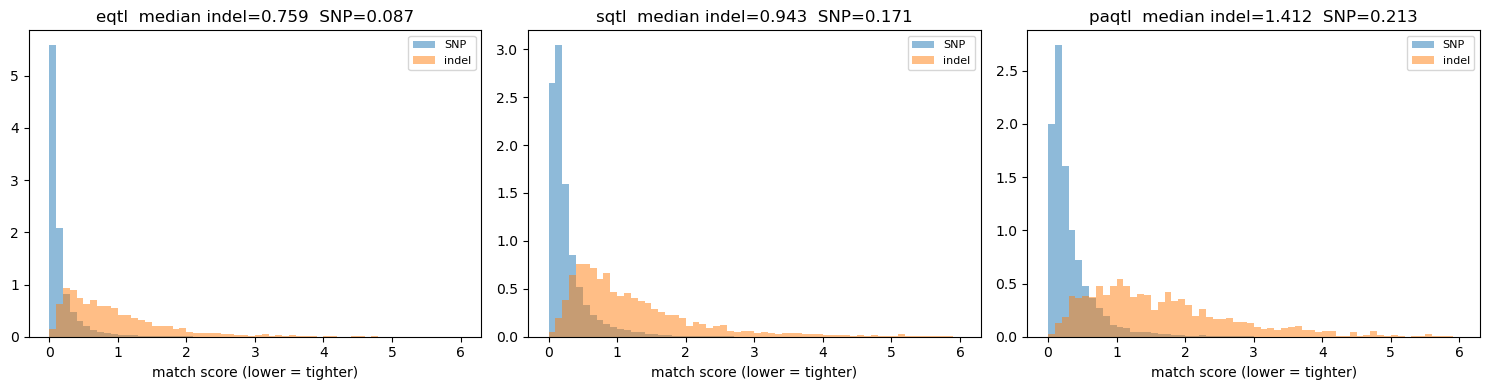

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, MODS):
    snp = qc_lib.load_matches(SNP_DIR, m)
    for s, label in [(snp.score, "SNP"),
                     (match[m].score - match[m].mismatch, "indel")]:
        ax.hist(s.dropna(), bins=60, range=(0, 6), alpha=0.5, density=True, label=label)
    ax.set_xlabel("match score (lower = tighter)")
    ax.set_title(f"{m}  median indel={(match[m].score - match[m].mismatch).median():.3f}"
                 f"  SNP={snp.score.median():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()